Memproses Down Sampling...


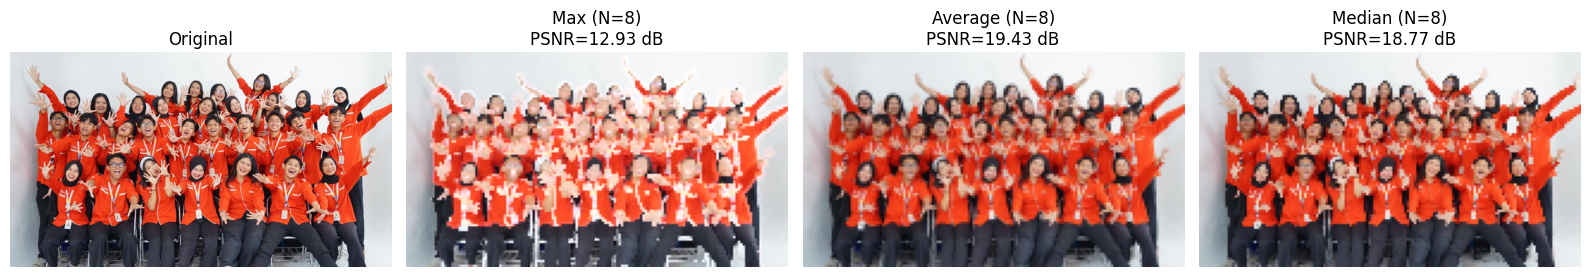

PSNR Max     : 12.93 dB
PSNR Average : 19.43 dB
PSNR Median  : 18.77 dB


In [43]:
# DOWN SAMPLING
import numpy as np
import matplotlib.pyplot as plt
import cv2

# read gambar
filename = 'gambar 1.jpeg'
img = cv2.imread(filename)

if img is None:
    print(f"Gambar '{filename}' tidak ditemukan!")
else:
    # ubah warna dari BGR ke RGB supaya sesuai
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # gambar dibagi blok kecil, tiap blok diwakili 1 nilai piksel
    def downsample(image, factor, method):
        h, w, c = image.shape
        new_h = h // factor
        new_w = w // factor
        output = np.zeros((new_h, new_w, c), dtype=np.uint8)

        for i in range(new_h):
            for j in range(new_w):
                # ambil satu blok ukuran factor x factor
                block = image[i*factor:(i+1)*factor, j*factor:(j+1)*factor]

                if method == 'max':
                    output[i, j] = np.max(block, axis=(0, 1))
                elif method == 'average':
                    output[i, j] = np.mean(block, axis=(0, 1))
                elif method == 'median':
                    output[i, j] = np.median(block, axis=(0, 1))

        return output

    # fungsi menghitung PSNR (dalam dB), makin tinggi nilainya makin mirip dengan aslinya
    def psnr(original, hasil):
        mse = np.mean((original.astype(float) - hasil.astype(float)) ** 2)
        if mse == 0:
            return float('inf')
        return 20 * np.log10(255.0 / np.sqrt(mse))

    factor = 8

    print("Proses Down Sampling...")
    img_max = downsample(img_rgb, factor, 'max')
    img_avg = downsample(img_rgb, factor, 'average')
    img_med = downsample(img_rgb, factor, 'median')

    # supaya bisa dibandingkan dengan gambar asli, hasil downsampling
    # dibesarkan lagi ke ukuran awal pakai nearest neighbor
    h, w = img_rgb.shape[:2]
    max_resized = cv2.resize(img_max, (w, h), interpolation=cv2.INTER_NEAREST)
    avg_resized = cv2.resize(img_avg, (w, h), interpolation=cv2.INTER_NEAREST)
    med_resized = cv2.resize(img_med, (w, h), interpolation=cv2.INTER_NEAREST)

    # hitung PSNR untuk tiap metode
    psnr_max = psnr(img_rgb, max_resized)
    psnr_avg = psnr(img_rgb, avg_resized)
    psnr_med = psnr(img_rgb, med_resized)

    # tampilkan hasil
    fig, ax = plt.subplots(1, 4, figsize=(16, 4))

    ax[0].imshow(img_rgb); ax[0].set_title("Original")
    ax[1].imshow(img_max); ax[1].set_title(f"Max (N={factor})\nPSNR={psnr_max:.2f} dB")
    ax[2].imshow(img_avg); ax[2].set_title(f"Average (N={factor})\nPSNR={psnr_avg:.2f} dB")
    ax[3].imshow(img_med); ax[3].set_title(f"Median (N={factor})\nPSNR={psnr_med:.2f} dB")

    for a in ax:
        a.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"PSNR Max     : {psnr_max:.2f} dB")
    print(f"PSNR Average : {psnr_avg:.2f} dB")
    print(f"PSNR Median  : {psnr_med:.2f} dB")

Memproses Up Sampling...


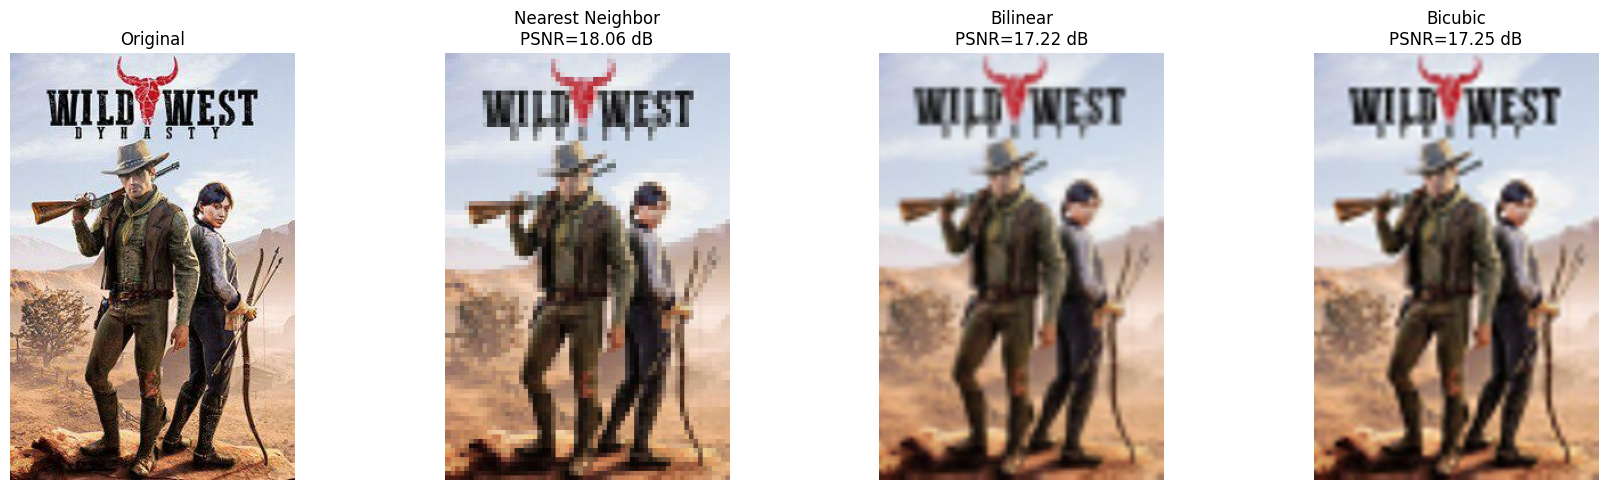

PSNR Nearest Neighbor : 18.06 dB
PSNR Bilinear         : 17.22 dB
PSNR Bicubic          : 17.25 dB


In [42]:
# UP SAMPLING
import numpy as np
import matplotlib.pyplot as plt
import cv2

# baca gambar ukuran asli, nanti dikecilkan dulu sebagai simulasi gambar resolusi rendah
filename = 'picture 1.jpeg'
img = cv2.imread(filename)

if img is None:
    print(f"Gambar '{filename}' tidak ditemukan!")
else:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    # rumus untuk interpolasi bicubic
    def cubic_kernel(x, a=-0.5):
        x = abs(x)
        if x <= 1:
            return (a + 2) * (x**3) - (a + 3) * (x**2) + 1
        elif x < 2:
            return a * (x**3) - 5*a * (x**2) + 8*a*x - 4*a
        return 0

    # fungsi upsampling untuk memperbesar gambar dengan 3 metode
    # target_h dan target_w dipakai supaya ukuran hasil pasti sama dengan gambar asli
    def upsample(image, target_h, target_w, method):
        ih, iw, c = image.shape
        new_h, new_w = target_h, target_w
        output = np.zeros((new_h, new_w, c), dtype=np.float32)

        scale_y = new_h / ih
        scale_x = new_w / iw

        if method == 'nn':
            # nearest neighbor, ambil piksel terdekat
            for i in range(new_h):
                for j in range(new_w):
                    src_i = min(int(i / scale_y), ih - 1)
                    src_j = min(int(j / scale_x), iw - 1)
                    output[i, j] = image[src_i, src_j]

        elif method == 'bilinear':
            # bilinear: rata-rata tertimbang dari 4 piksel tetangga
            for i in range(new_h):
                for j in range(new_w):
                    y = i / scale_y
                    x = j / scale_x

                    y1 = int(np.floor(y))
                    x1 = int(np.floor(x))
                    y2 = min(y1 + 1, ih - 1)
                    x2 = min(x1 + 1, iw - 1)

                    dy = y - y1
                    dx = x - x1

                    top = (1-dx) * image[y1, x1] + dx * image[y1, x2]
                    bottom = (1-dx) * image[y2, x1] + dx * image[y2, x2]
                    output[i, j] = (1-dy) * top + dy * bottom

        elif method == 'bicubic':
            # bicubic, memakai 16 piksel tetangga dengan bobot kurva kubik
            padded = np.pad(image, ((1, 2), (1, 2), (0, 0)), mode='edge')
            for i in range(new_h):
                for j in range(new_w):
                    y = i / scale_y
                    x = j / scale_x

                    y_int = int(np.floor(y))
                    x_int = int(np.floor(x))
                    dy = y - y_int
                    dx = x - x_int

                    pixel = np.zeros(c)
                    for m in range(-1, 3):
                        for n in range(-1, 3):
                            weight = cubic_kernel(m - dy) * cubic_kernel(n - dx)
                            pixel += padded[y_int + m + 1, x_int + n + 1] * weight

                    output[i, j] = pixel

        return np.clip(output, 0, 255).astype(np.uint8)

    # fungsi menghitung PSNR (dalam dB), makin tinggi nilainya makin mirip dengan aslinya
    def psnr(original, hasil):
        mse = np.mean((original.astype(float) - hasil.astype(float)) ** 2)
        if mse == 0:
            return float('inf')
        return 20 * np.log10(255.0 / np.sqrt(mse))

    scale_down = 4  # kecilkan dulu gambar sebagai simulasi resolusi rendah
    small_img = cv2.resize(img_rgb, (w // scale_down, h // scale_down), interpolation=cv2.INTER_AREA)

    print("Memproses Up Sampling...")
    # h, w diambil dari ukuran gambar asli, supaya hasil upsampling ukurannya pas
    img_nn = upsample(small_img, h, w, 'nn')
    img_bilinear = upsample(small_img, h, w, 'bilinear')
    img_bicubic = upsample(small_img, h, w, 'bicubic')

    # hitung PSNR dibandingkan gambar asli
    psnr_nn = psnr(img_rgb, img_nn)
    psnr_bilinear = psnr(img_rgb, img_bilinear)
    psnr_bicubic = psnr(img_rgb, img_bicubic)

    # tampilkan hasil
    fig, ax = plt.subplots(1, 4, figsize=(18, 5))

    ax[0].imshow(img_rgb); ax[0].set_title("Original")
    ax[1].imshow(img_nn); ax[1].set_title(f"Nearest Neighbor\nPSNR={psnr_nn:.2f} dB")
    ax[2].imshow(img_bilinear); ax[2].set_title(f"Bilinear\nPSNR={psnr_bilinear:.2f} dB")
    ax[3].imshow(img_bicubic); ax[3].set_title(f"Bicubic\nPSNR={psnr_bicubic:.2f} dB")

    for a in ax:
        a.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"PSNR Nearest Neighbor : {psnr_nn:.2f} dB")
    print(f"PSNR Bilinear         : {psnr_bilinear:.2f} dB")
    print(f"PSNR Bicubic          : {psnr_bicubic:.2f} dB")